# EDA: PPE Compliance Detection Dataset

Exploratory analysis of the construction-site-safety PPE dataset (Roboflow Universe, v28). All plotting logic lives in `src/eda.py` and is imported here rather than duplicated -- this notebook is for exploration and narration only.

Full citation and dataset notes: see `../README.md` and `../BUILD_LOG.md`.

In [1]:
import sys
sys.path.append('..')

from src.config import CLASS_NAMES, DATA_DIR
from src.eda import (
    class_counts_per_split,
    plot_boxes_per_image,
    plot_class_distribution,
    plot_image_size_distribution,
    plot_sample_grid,
)
from IPython.display import Image

## Dataset overview

In [2]:
for split in ['train', 'valid', 'test']:
    n = len(list((DATA_DIR / split / 'images').glob('*.jpg')))
    print(f'{split}: {n} images')
print()
print('classes:', CLASS_NAMES)

train: 2605 images
valid: 114 images
test: 82 images

classes: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


## Class distribution by split

In [3]:
counts = class_counts_per_split()
for split, c in counts.items():
    print(split, dict(c.most_common()))

train {'Person': 9532, 'machinery': 5247, 'NO-Safety Vest': 3962, 'Safety Cone': 3366, 'Hardhat': 3145, 'NO-Mask': 3097, 'Safety Vest': 3033, 'NO-Hardhat': 2317, 'Mask': 1651, 'vehicle': 1545}
valid {'Person': 166, 'NO-Safety Vest': 106, 'Hardhat': 79, 'NO-Mask': 74, 'NO-Hardhat': 69, 'machinery': 55, 'Safety Cone': 44, 'vehicle': 42, 'Safety Vest': 41, 'Mask': 21}
test {'Person': 174, 'Hardhat': 110, 'Safety Cone': 92, 'NO-Safety Vest': 90, 'NO-Mask': 79, 'Safety Vest': 61, 'machinery': 44, 'vehicle': 41, 'NO-Hardhat': 41, 'Mask': 28}


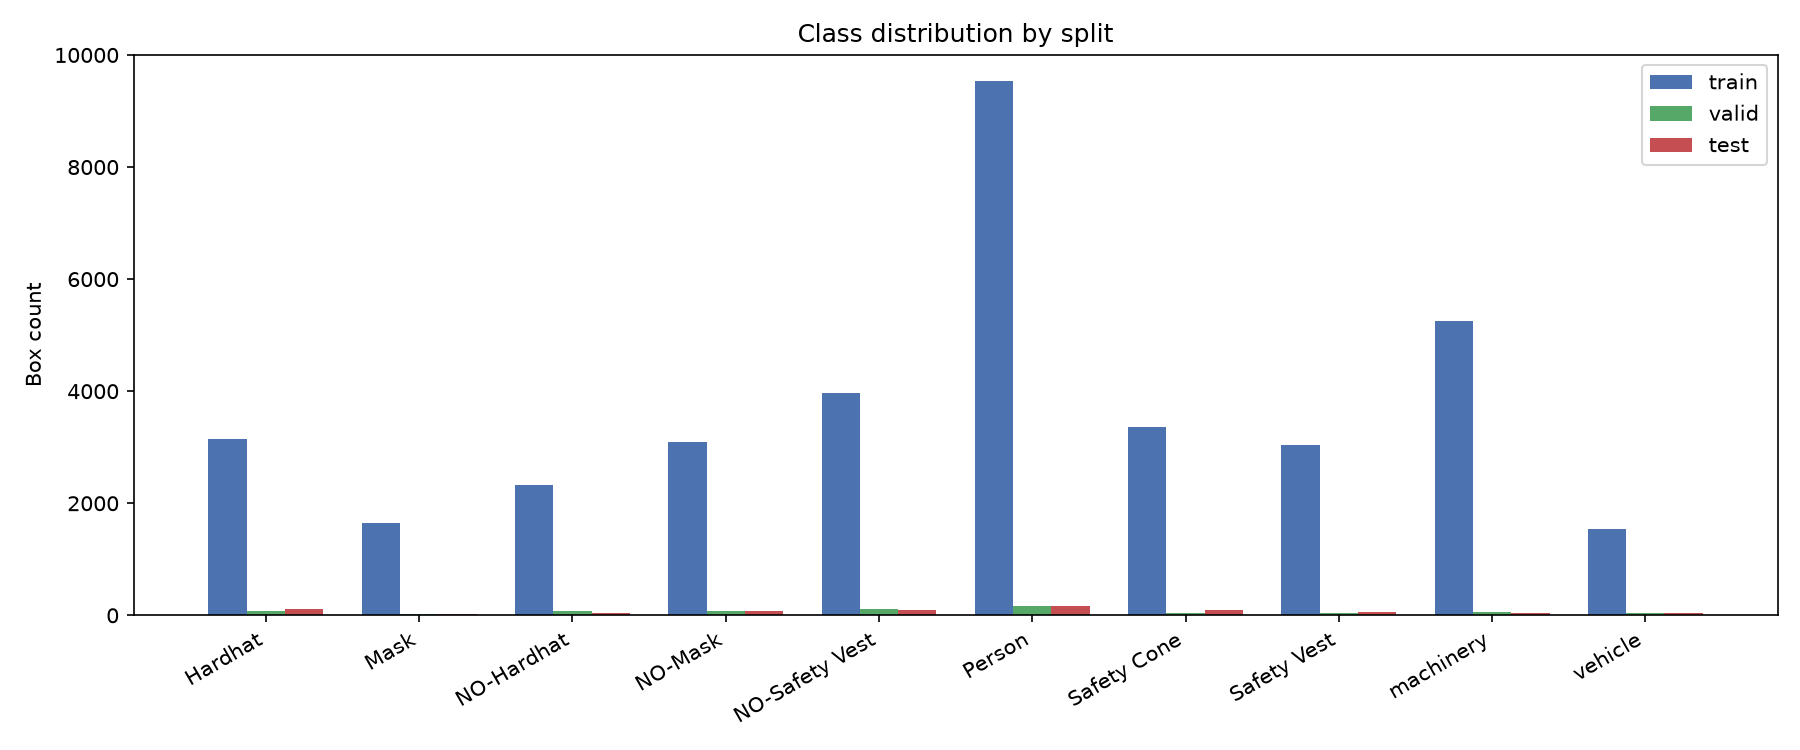

In [4]:
plot_class_distribution()
Image('../figures/class_distribution.png')

`Person` dominates (as expected -- most images have multiple visible people), and `Mask`/`vehicle` are the least represented classes. All three `NO-*` violation classes have reasonable representation (2,000-4,000 boxes each in train), which matters most since correctly detecting a *missing* item of PPE is the safety-relevant failure mode -- see MODEL_CARD.md.

## Annotation density

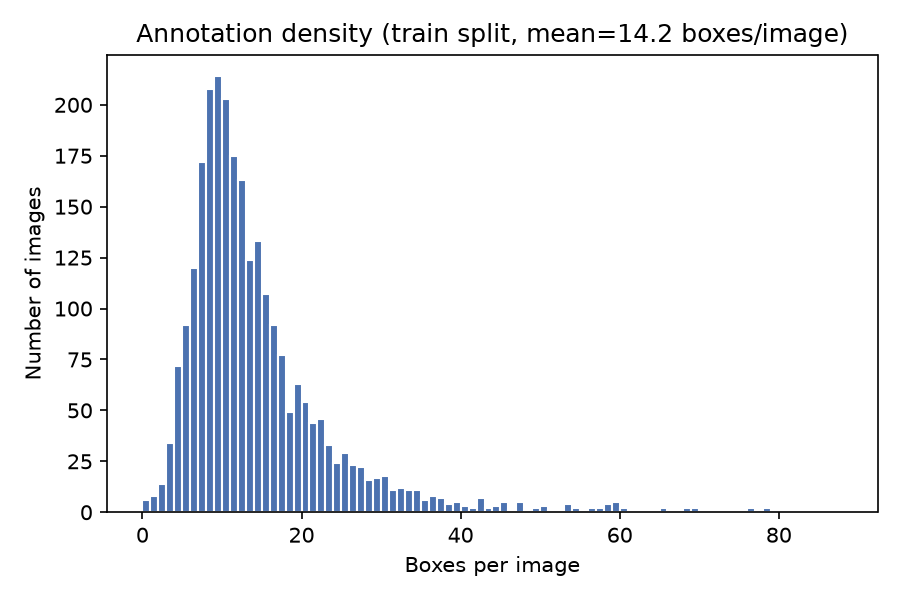

In [5]:
plot_boxes_per_image()
Image('../figures/boxes_per_image.png')

Mean of ~14 boxes per training image is unusually dense for a single photo -- investigated below.

## Image size distribution

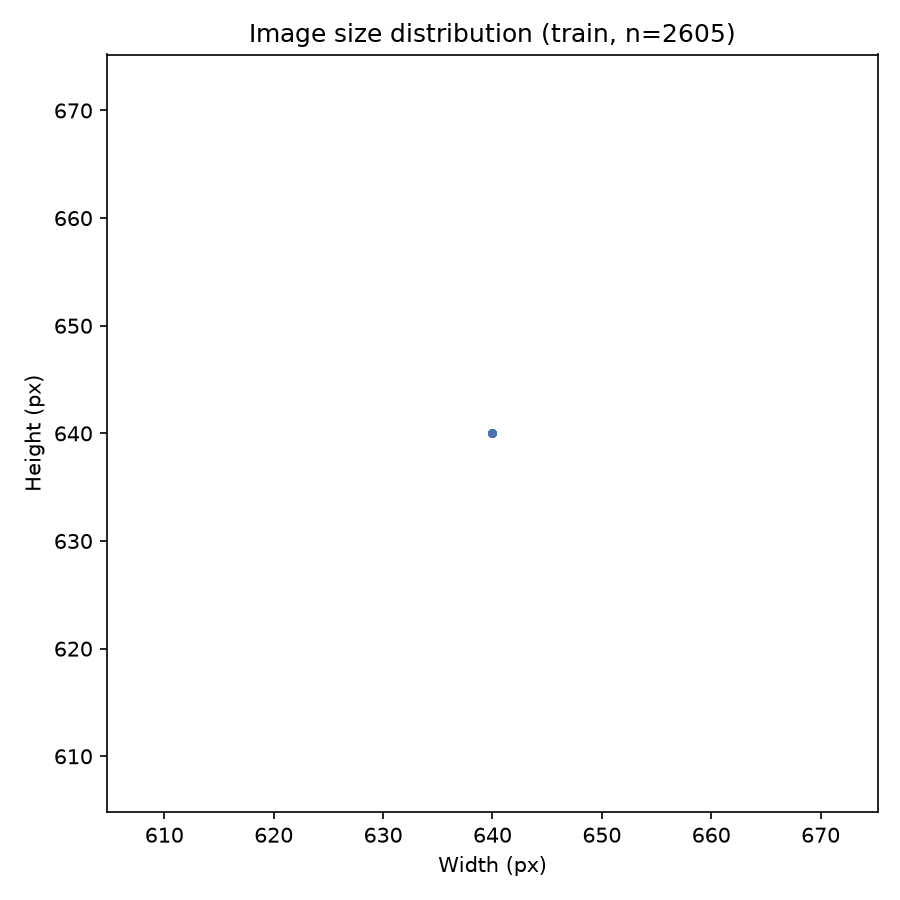

In [6]:
plot_image_size_distribution()
Image('../figures/image_size_distribution.png')

## Sample annotated images

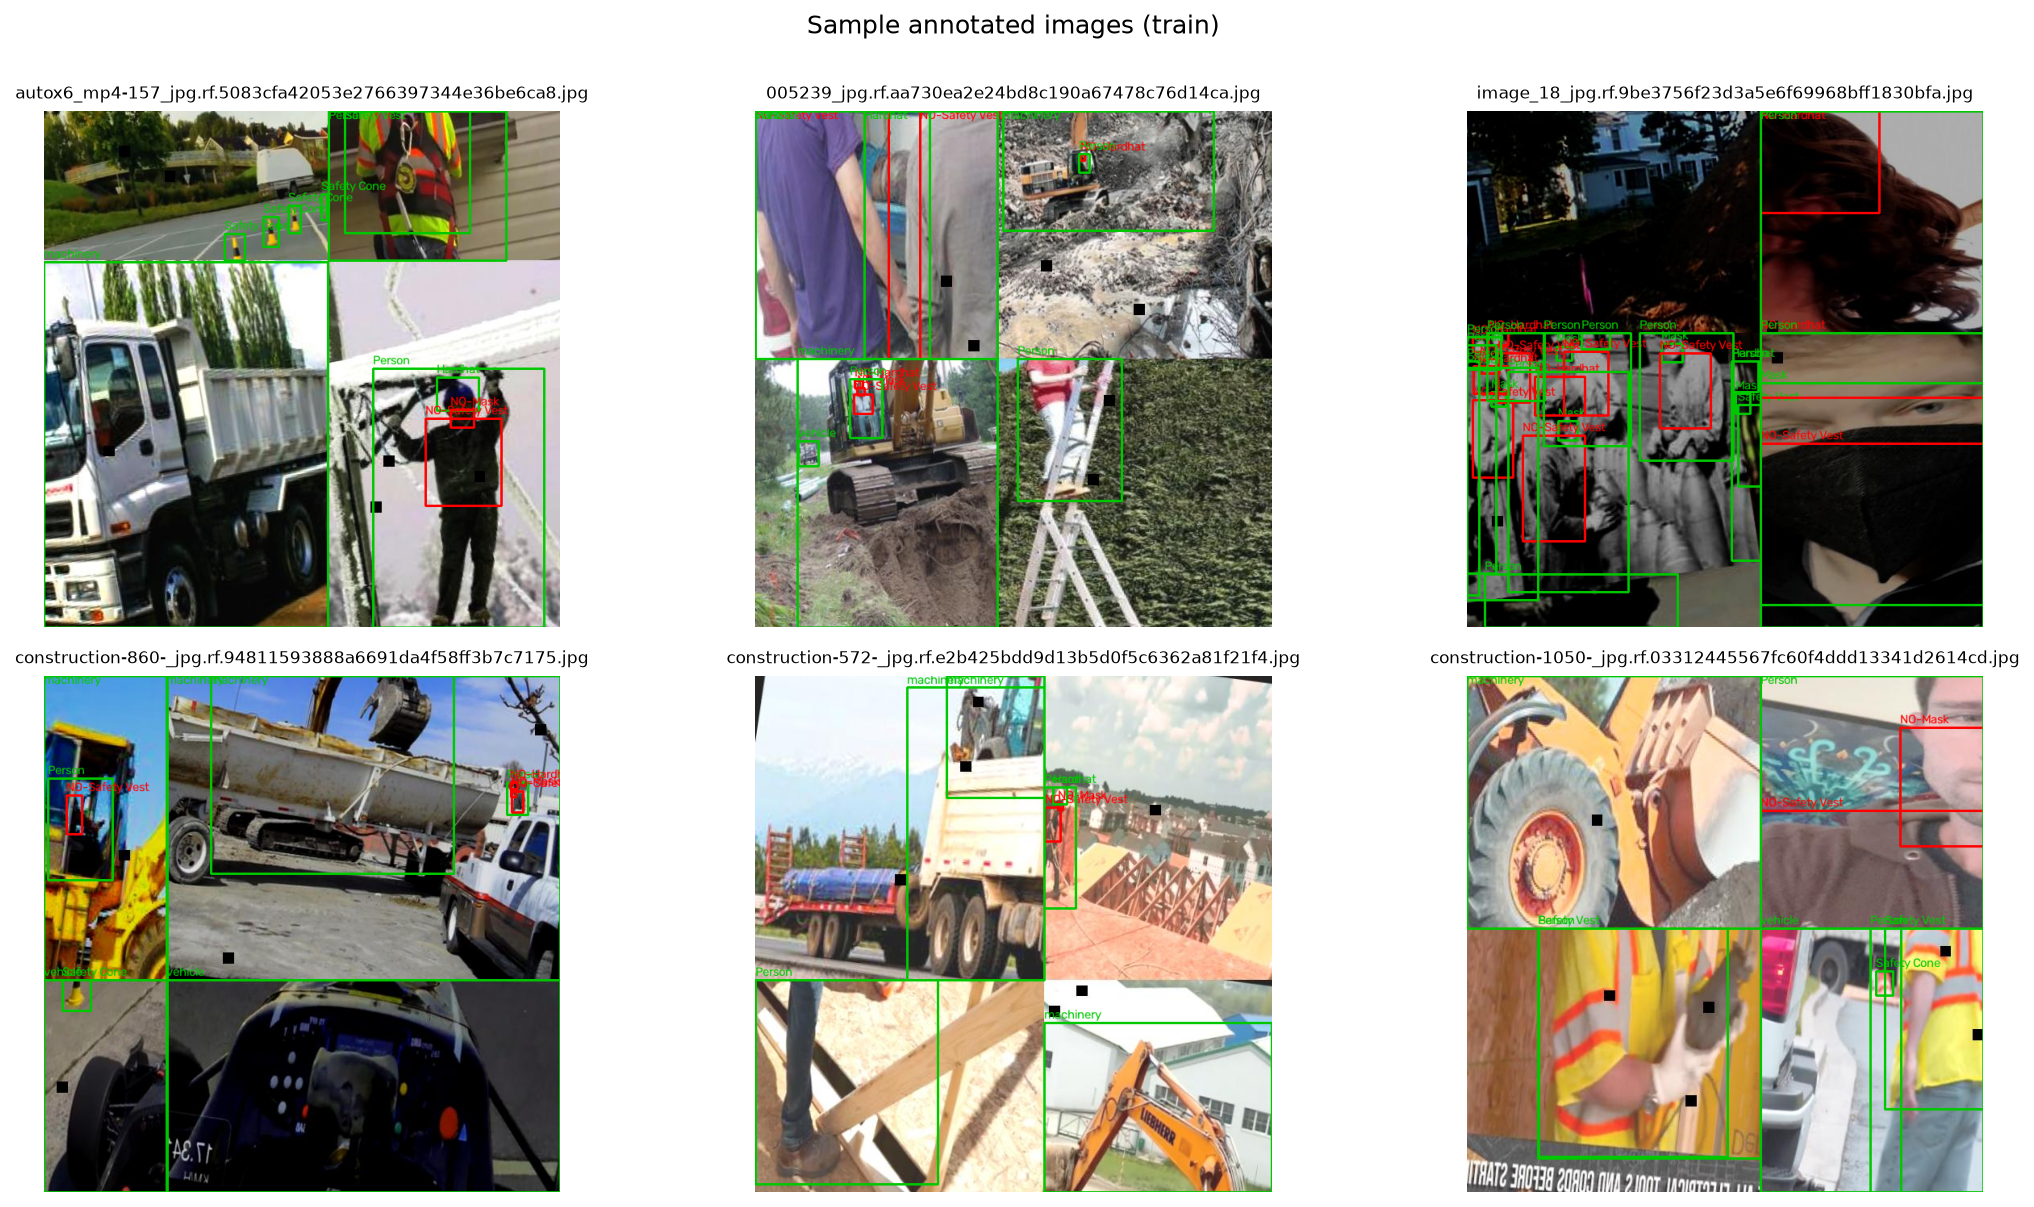

In [7]:
plot_sample_grid('train', n=6)
Image('../figures/sample_annotations_train.png')

**Finding:** a meaningful fraction of the images in this dataset are themselves 2x2 photo mosaics baked in at export time by Roboflow (not an artifact of this notebook's plotting) -- four unrelated construction-site photos tiled into one image, each quadrant separately annotated. This explains the high mean boxes-per-image above: it is really closer to ~3.5 boxes per *sub-photo*. YOLO training treats each mosaic tile's objects as normal boxes on a normal image, so this does not break training, but it does mean the model sees some images with an unusual four-panel layout it would not see at real inference time -- noted as a limitation in MODEL_CARD.md.

## Takeaways

- 10 classes, reasonable per-class support across all three `NO-*` violation classes -- the classes that matter most for a compliance-monitoring use case.
- `Person`, `machinery`, and `NO-Safety Vest` are the most frequent classes; `Mask` and `vehicle` the least -- worth watching in the per-class evaluation.
- A subset of source images are pre-tiled 2x2 mosaics, inflating raw boxes-per-image and introducing a layout the model won't see at real deployment time. Documented, not hidden.